# 02: Exploratory Data Analysis (training set only)

Rules for this notebook:
- Only the training set is loaded. The test set stays locked until final evaluation.
- Findings are associations in this dataset, not causes.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config import TARGET_COL, TRAIN_DATA_PATH
from src.data.schema import CATEGORICAL_COLUMNS, NUMERIC_COLUMNS, ORDINAL_COLUMNS

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

if not TRAIN_DATA_PATH.exists():
    raise FileNotFoundError("train.csv not found. Run: python -m src.data.split_data")

train = pd.read_csv(TRAIN_DATA_PATH)
print("Training set:", train.shape)

Training set: (1176, 32)


,count,percent
Attrition,,
No,986,83.8
Yes,190,16.2


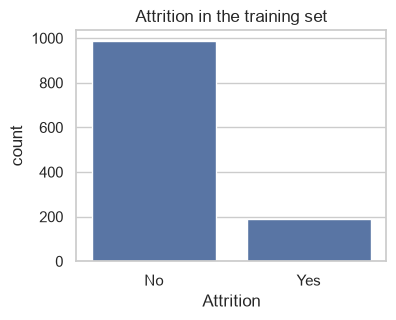

In [2]:
counts = train[TARGET_COL].value_counts()
summary = pd.DataFrame({"count": counts, "percent": (counts / len(train) * 100).round(1)})
display(summary)

fig, ax = plt.subplots(figsize=(4, 3))
sns.countplot(data=train, x=TARGET_COL, order=["No", "Yes"], ax=ax)
ax.set_title("Attrition in the training set")
plt.show()

In [3]:
numeric_summary = train[NUMERIC_COLUMNS].describe().T
numeric_summary["skew"] = train[NUMERIC_COLUMNS].skew().round(2)
display(numeric_summary.round(2))

,count,mean,std,min,25%,50%,75%,max,skew
Age,1176.0,37.00,9.18,18.0,30.00,36.0,43.00,60.0,0.40
DailyRate,1176.0,803.99,401.34,103.0,467.75,799.5,1157.00,1499.0,-0.00
DistanceFromHome,1176.0,9.36,8.18,1.0,2.00,7.0,14.00,29.0,0.93
HourlyRate,1176.0,65.50,20.37,30.0,48.00,66.0,83.00,100.0,-0.01
MonthlyIncome,1176.0,6544.02,4653.74,1009.0,2948.00,5004.5,8420.50,19973.0,1.33
MonthlyRate,1176.0,14390.24,7192.83,2094.0,8051.00,14373.0,20770.75,26999.0,0.00
NumCompaniesWorked,1176.0,2.69,2.49,0.0,1.00,2.0,4.00,9.0,1.00
PercentSalaryHike,1176.0,15.24,3.68,11.0,12.00,14.0,18.00,25.0,0.81
TotalWorkingYears,1176.0,11.36,7.80,0.0,6.00,10.0,15.00,40.0,1.10
TrainingTimesLastYear,1176.0,2.76,1.26,0.0,2.00,3.0,3.00,6.0,0.61


In [4]:
def plot_grid(columns, plot_fn, n_cols=4, cell_size=(4, 3)):
    """Draw one small plot per column in a grid."""
    n_rows = -(-len(columns) // n_cols)  # ceiling division
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(cell_size[0] * n_cols, cell_size[1] * n_rows))
    axes = axes.flatten()
    for ax, col in zip(axes, columns):
        plot_fn(col, ax)
        ax.set_title(col)
        ax.set_xlabel("")
    for ax in axes[len(columns):]:
        ax.set_visible(False)
    fig.tight_layout()
    plt.show()

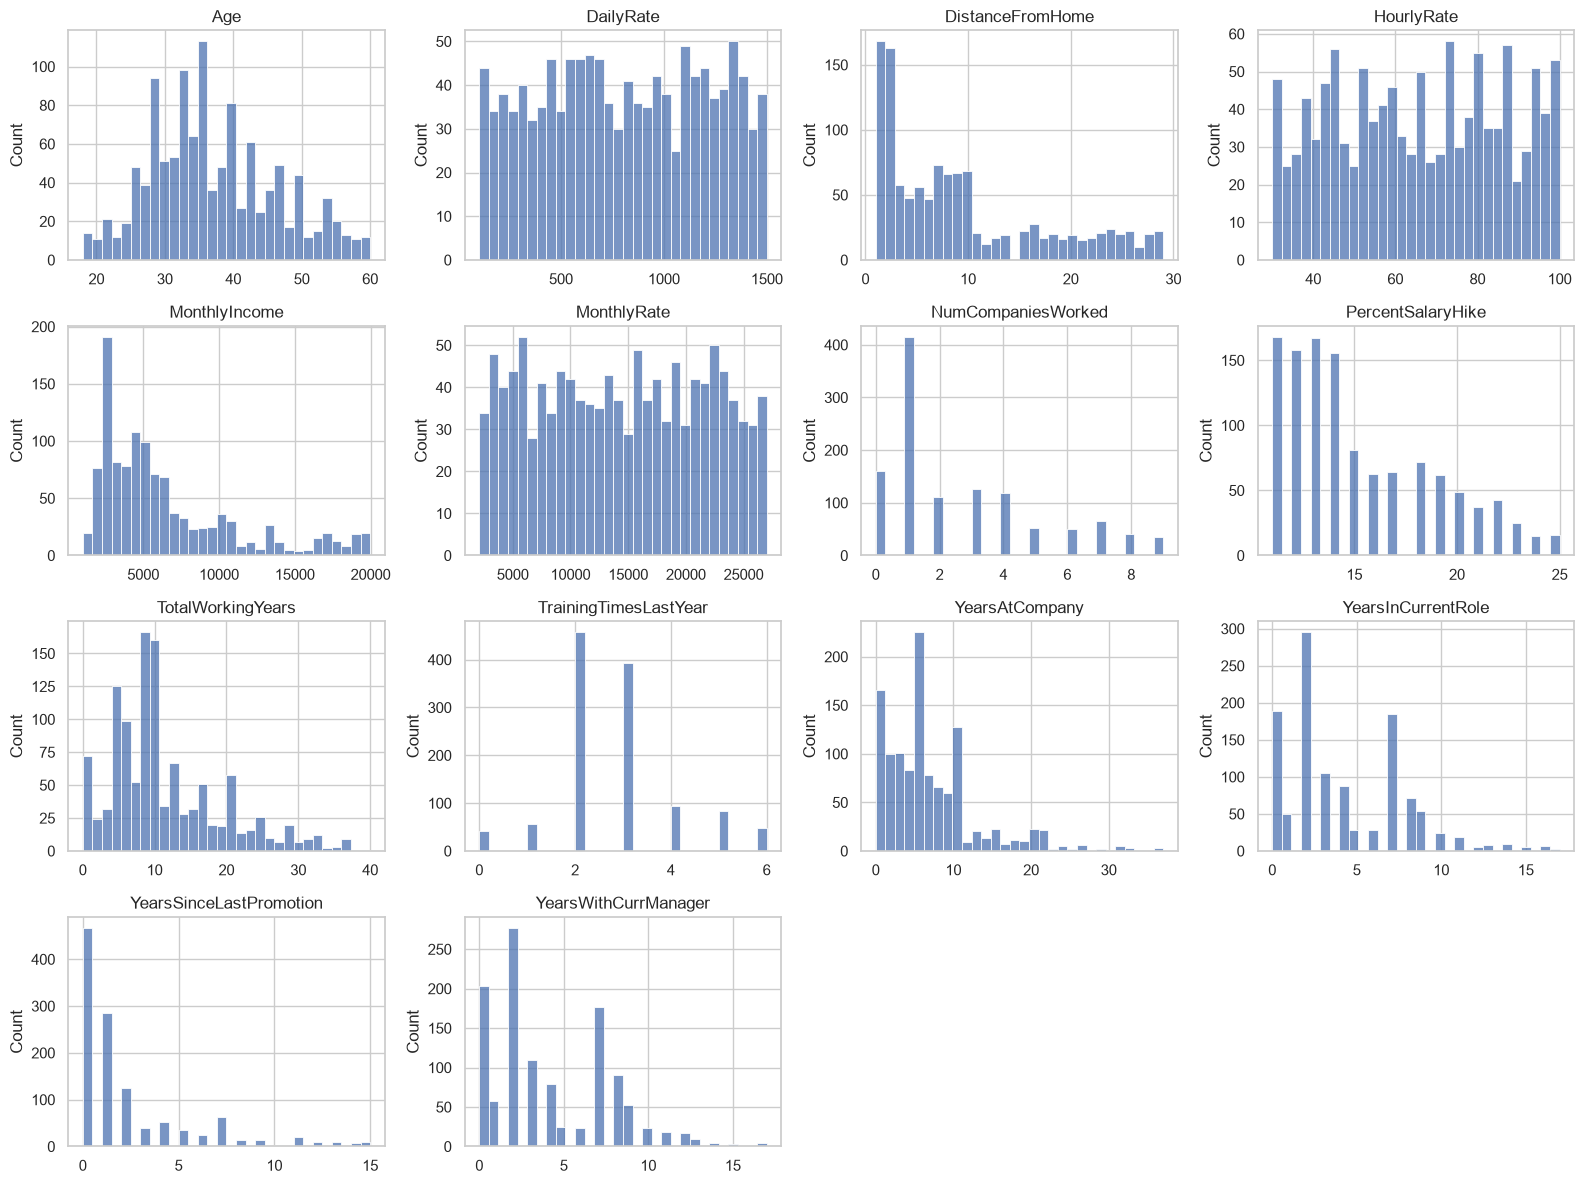

In [5]:
plot_grid(NUMERIC_COLUMNS, lambda c, ax: sns.histplot(train[c], bins=30, ax=ax))

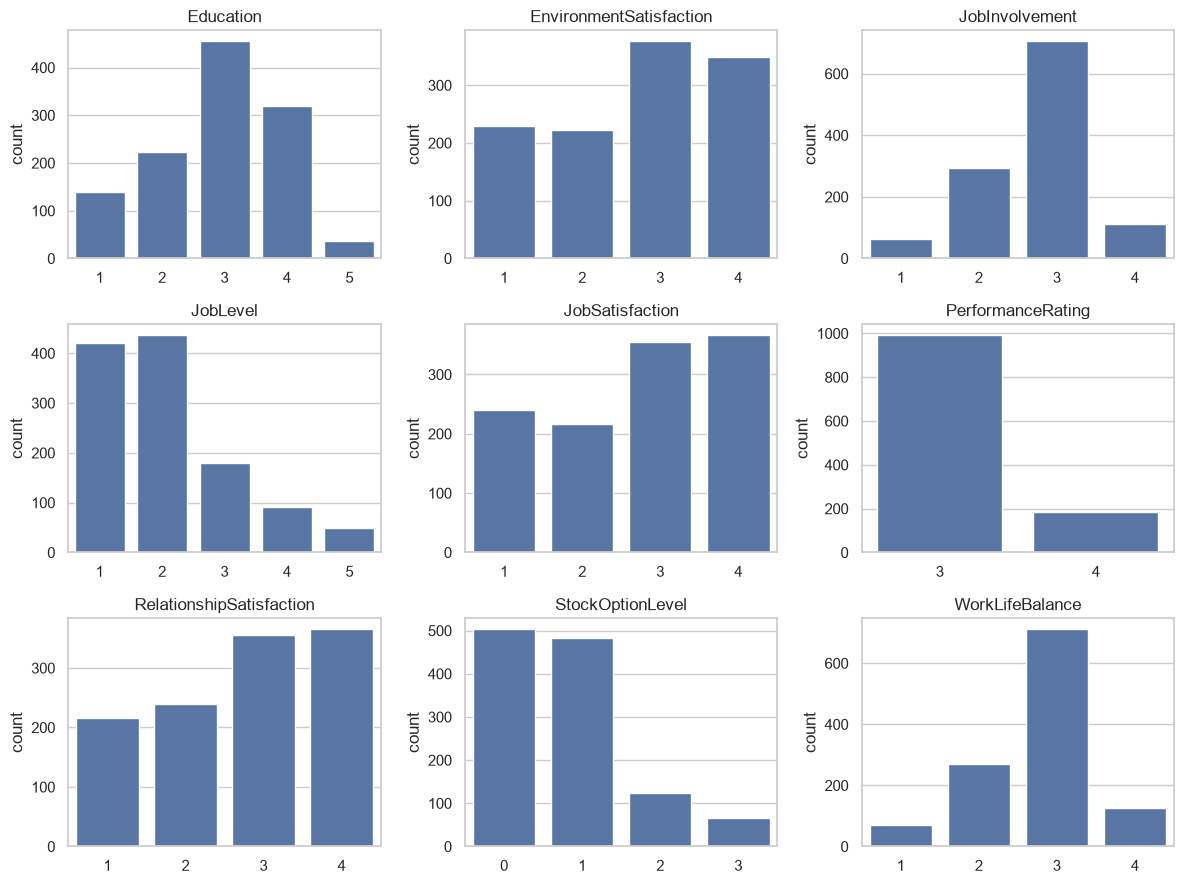

In [6]:
plot_grid(ORDINAL_COLUMNS, lambda c, ax: sns.countplot(data=train, x=c, ax=ax), n_cols=3)

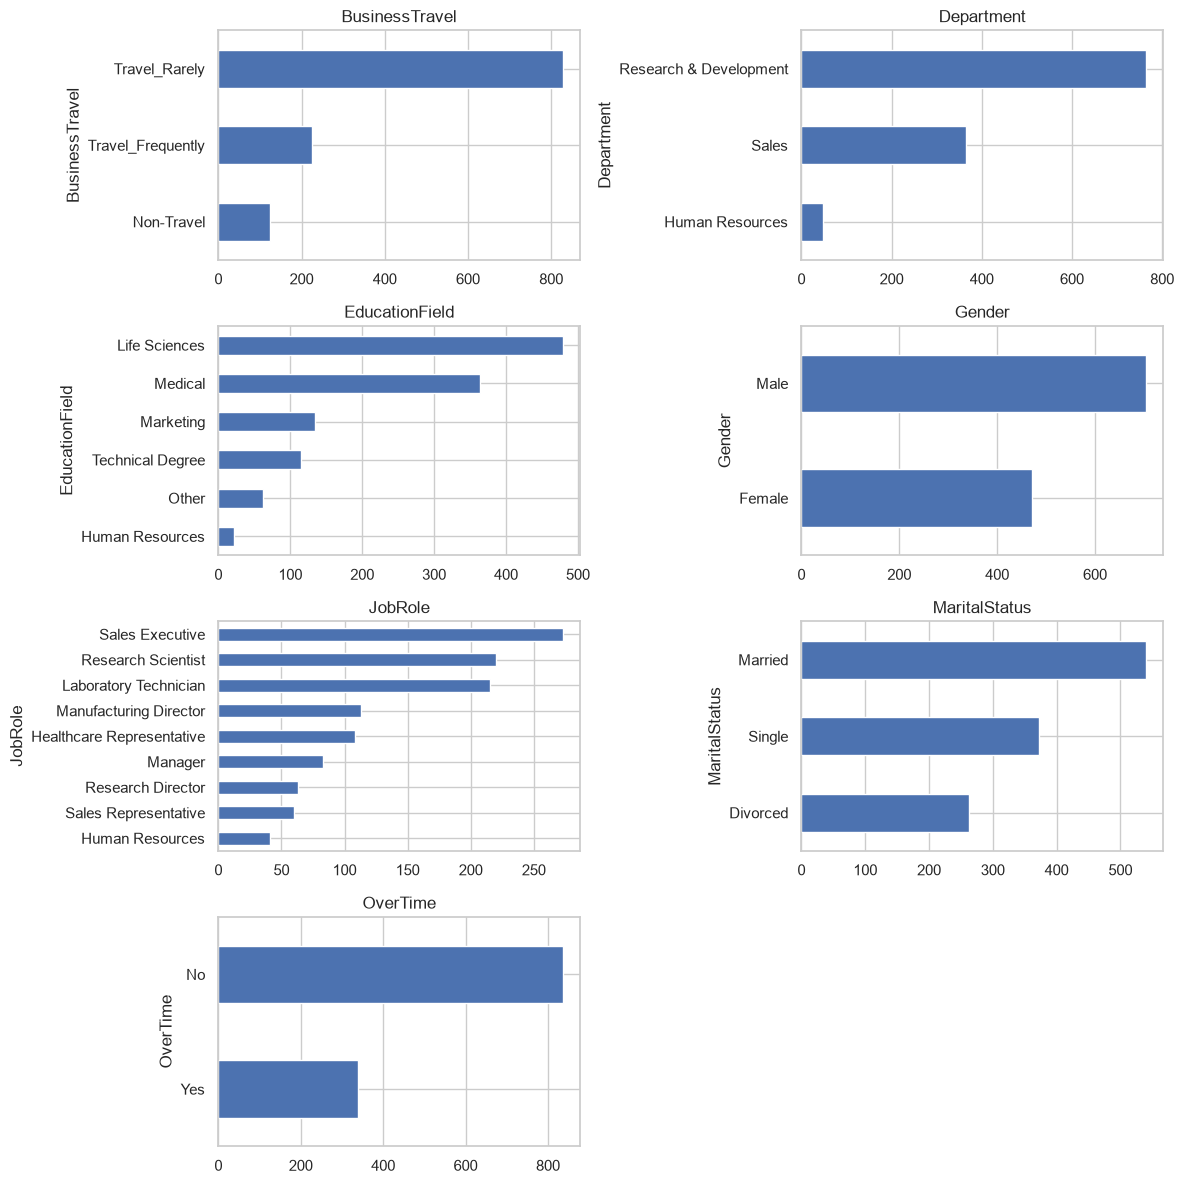

In [7]:
def barh(col, ax):
    train[col].value_counts().sort_values().plot.barh(ax=ax)


plot_grid(CATEGORICAL_COLUMNS, barh, n_cols=2, cell_size=(6, 3))

## Observations (to fill in after looking at the plots)
-## Observations (training set, univariate only)

**Target**
- About 16% attrition: imbalanced, so use stratified CV and PR-AUC/recall.

**Numeric**
- DailyRate, HourlyRate, MonthlyRate look roughly flat (random-like); candidates to drop pending bivariate check.
- MonthlyIncome, DistanceFromHome, YearsAtCompany, TotalWorkingYears, YearsSinceLastPromotion, PercentSalaryHike are right-skewed.
- NumCompaniesWorked and TrainingTimesLastYear behave like small counts.
- YearsInCurrentRole and YearsWithCurrManager look alike (peaks near 0, 2, 7): check correlation.
- Long tails look genuine, not errors; no outlier deletion.

**Ordinal**
- PerformanceRating has only values 3 and 4 (about 84% are 3): little variation.
- Rare levels (Education=5, WorkLifeBalance=1, JobInvolvement=1): noisy rates later.

**Categorical**
- Human Resources groups (Department, EducationField, JobRole) and Sales Representative are small.
- OverTime = Yes is about 29% of employees.

**Caveat:** these are distributions only; no relationship with attrition has been examined yet.

## Bivariate analysis: attrition rate by variable (training set only)

How to read each chart:
- Bar height = attrition rate in that group
- Whiskers = 95% interval (wide whiskers mean few people, so weak evidence)
- `n=` above each bar = group size
- Red dashed line = overall attrition rate in the training set

These are associations in this dataset, not causes.

In [8]:
from src.analysis.attrition_rates import attrition_rate_table

overall_rate = (train[TARGET_COL] == "Yes").mean()
print(f"Overall attrition rate (train): {overall_rate:.3f}")


def plot_rate(column, ax):
    """Bar chart of attrition rate per group, with 95% interval and group size."""
    table = attrition_rate_table(train, column)
    if not pd.api.types.is_numeric_dtype(train[column]):
        table = table.sort_values("attrition_rate", ascending=False).reset_index(drop=True)

    x = list(range(len(table)))
    err_low = (table["attrition_rate"] - table["ci_low"]).clip(lower=0)
    err_high = (table["ci_high"] - table["attrition_rate"]).clip(lower=0)
    ax.bar(x, table["attrition_rate"], yerr=[err_low, err_high], capsize=3, color="steelblue")
    ax.axhline(overall_rate, color="red", linestyle="--", linewidth=1)
    for i, row in table.iterrows():
        ax.text(i, row["ci_high"] + 0.01, f"n={int(row['n'])}", ha="center", fontsize=7)
    ax.set_xticks(x)
    ax.set_xticklabels(table["group"], rotation=45, ha="right", fontsize=8)
    ax.set_ylim(0, min(1.0, table["ci_high"].max() + 0.1))
    ax.set_ylabel("attrition rate")

Overall attrition rate (train): 0.162


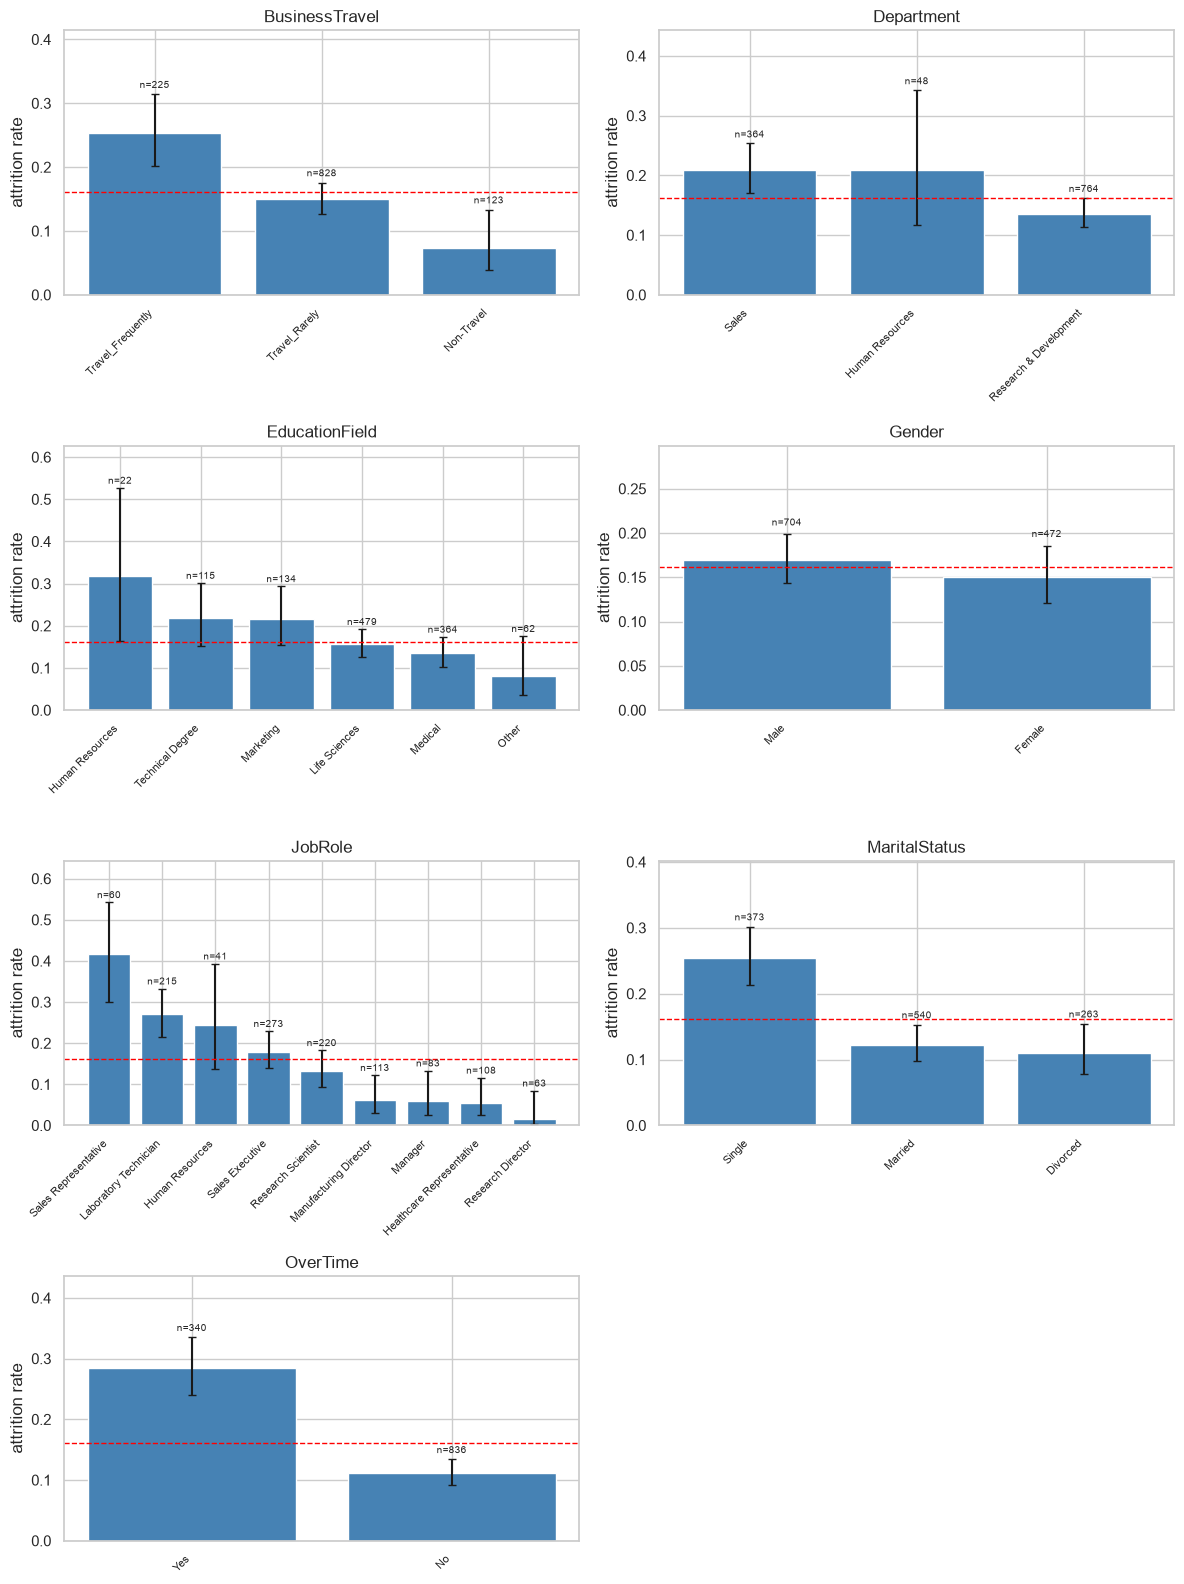

In [9]:
plot_grid(CATEGORICAL_COLUMNS, plot_rate, n_cols=2, cell_size=(6, 4))

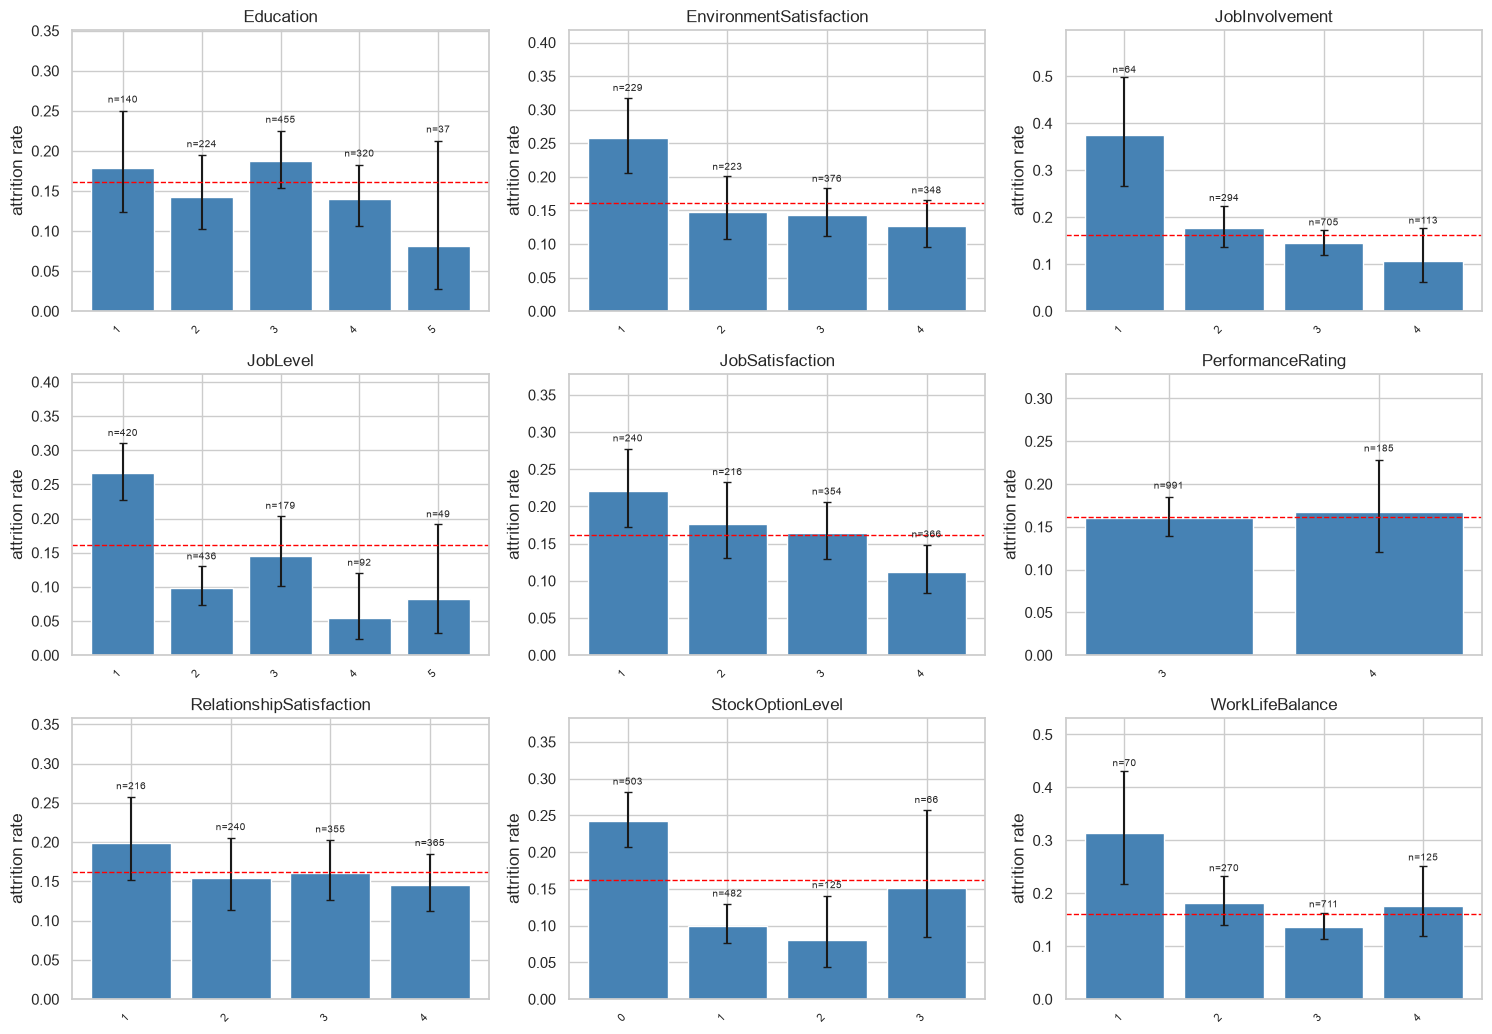

In [10]:
plot_grid(ORDINAL_COLUMNS, plot_rate, n_cols=3, cell_size=(5, 3.5))

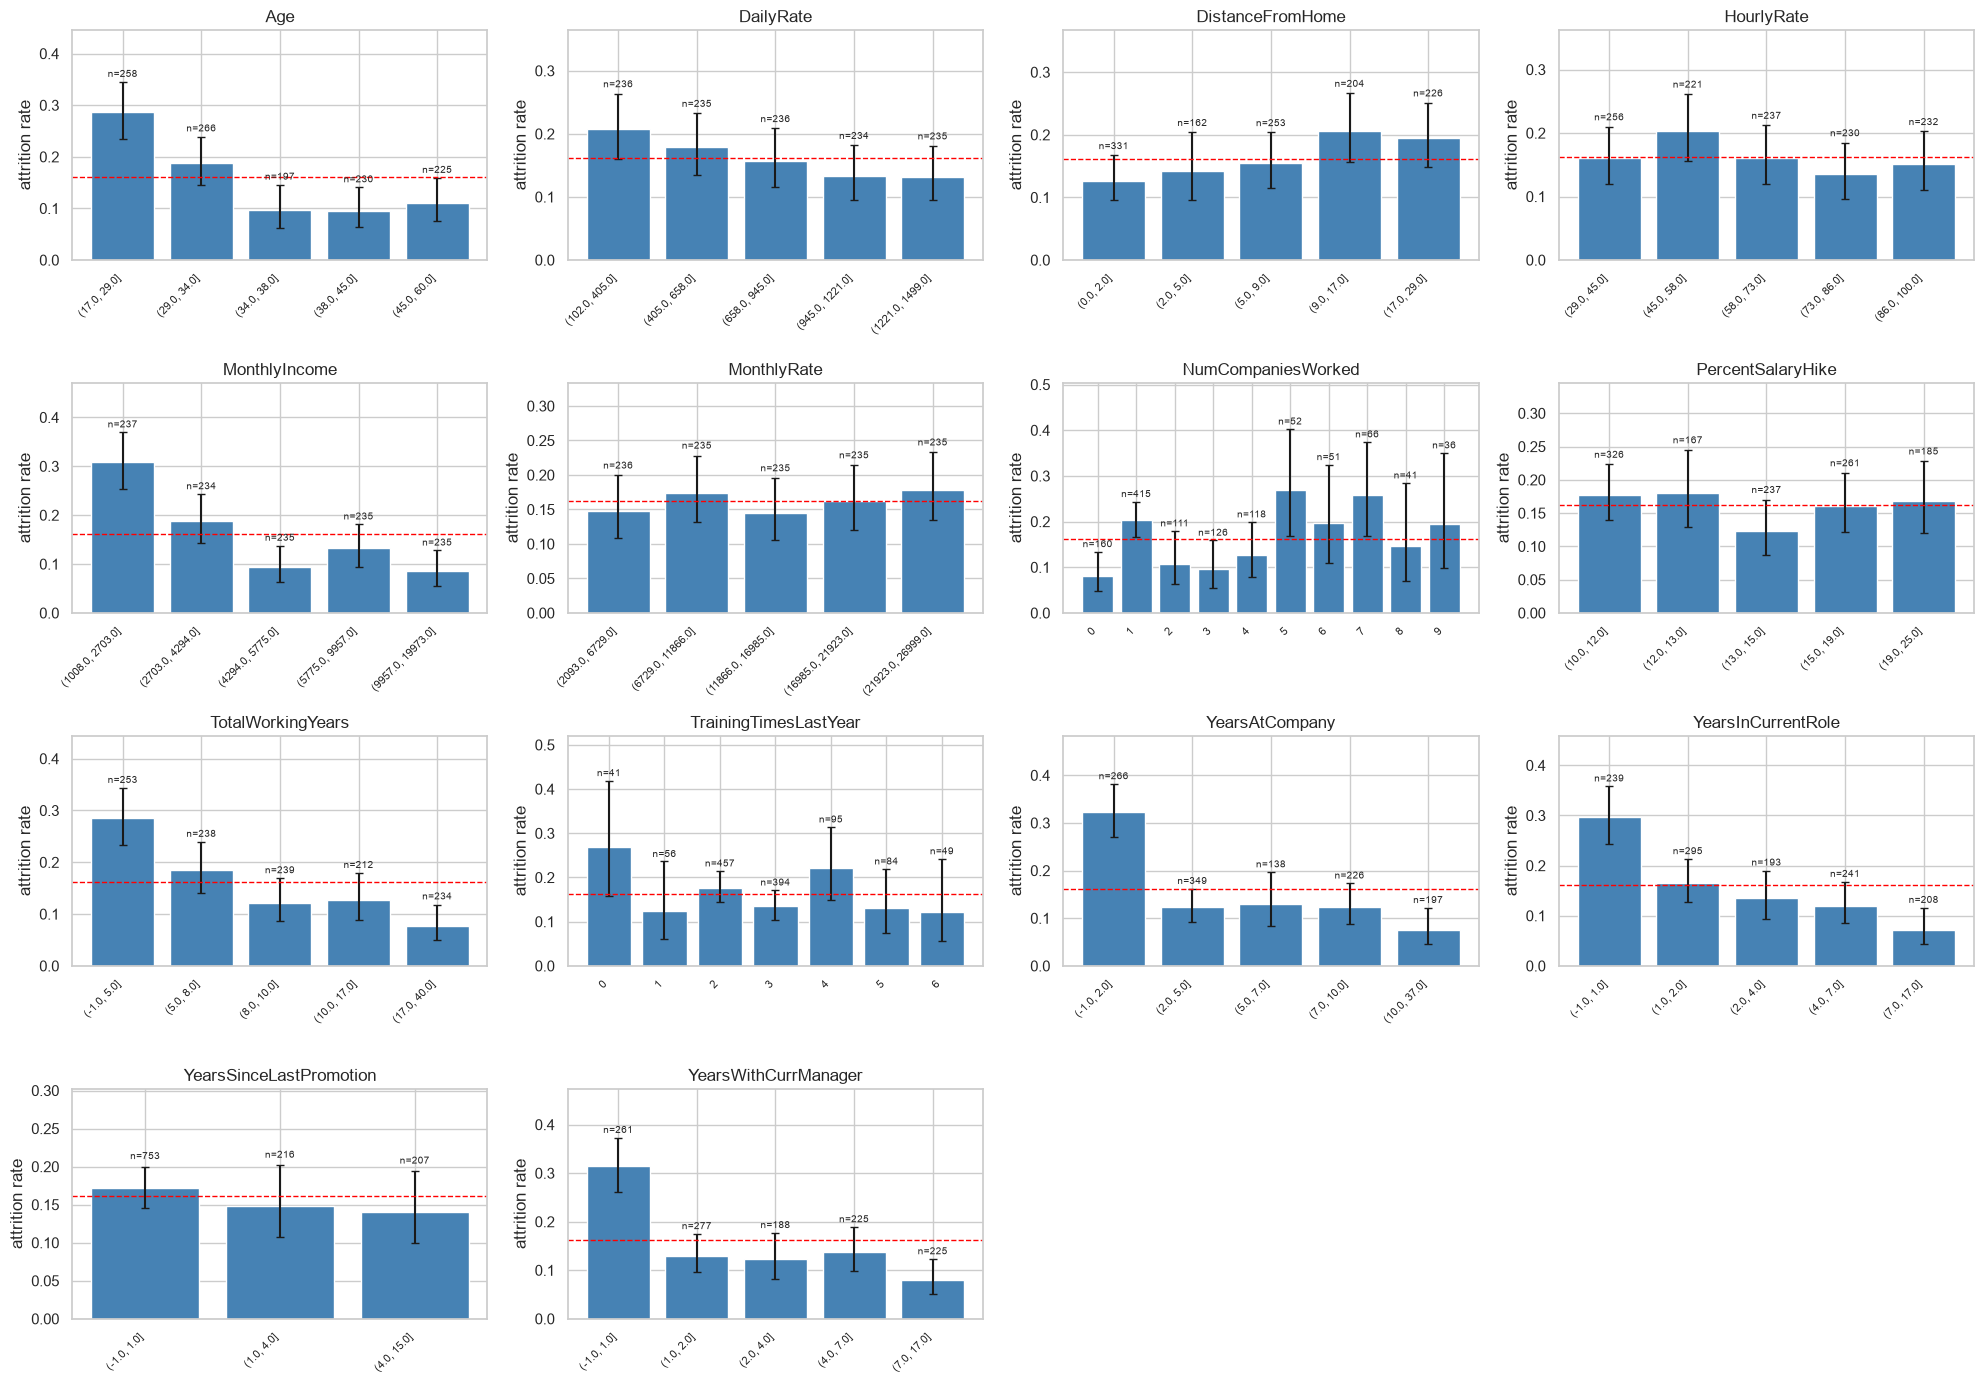

In [11]:
plot_grid(NUMERIC_COLUMNS, plot_rate, n_cols=4, cell_size=(5, 3.5))

## Bivariate observations (to fill in after looking at the plots)
-## Bivariate observations (training set; categorical features)

Overall attrition rate in training data is about 16%. Associations only, not causes.

- **OverTime**: Yes about 28% vs No about 11%; large groups, clear gap (strongest categorical signal).
- **JobRole**: spread from about 1% to 41%; Sales Representative and Laboratory Technician high; Research Director, Healthcare Representative, Manager, Manufacturing Director low. Several small groups (n=41 to 113).
- **MaritalStatus**: Single about 25% vs Married/Divorced about 11-12%.
- **BusinessTravel**: consistent step: Non-Travel about 7%, Travel_Rarely about 15%, Travel_Frequently about 25%.
- **Department**: Sales about 21% vs R&D about 13%; HR (n=48) inconclusive.
- **EducationField**: weak; most intervals overlap; HR (n=22) very uncertain.
- **Gender**: no clear difference.

Caveats: marginal rates (confounding possible); many comparisons; small groups give wide intervals.